Using the the ohsome now query assigning contributor skill level by their monthly and total skill levels

Differentiating additionally betweeen contributors who use AI and contributors who do not use AI

In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

In [2]:
pd.options.display.float_format = '{:20,.2f}'.format

In [3]:
ohsome = pd.read_csv(r"\data\input\ohsomeNow_user_timeseries.csv",delimiter =";")

In [4]:
filepath = r\data\input\ohsomeNow_user_timeseries.csv"

In [11]:
countries = ["AFG", "ALB", "BGD", "BOL", "BRN", "COL", "CYP", "ECU", "ETH", "B35", "GRC", "HUN", "IND", "KEN", "KHM", "KOR",
             "LAO", "MAR", "MKD", "MNE", "NGA", "NZ1", "PNG", "SAU", "SLE", "TUR", "TZA", "URY", "US1", "VNM"
            ]
placeholders = ", ".join(f"'{c}'" for c in countries)

In [15]:
con = duckdb.connect()
con.execute(f"""
    CREATE VIEW ob AS
    SELECT * FROM read_csv('{filepath}')
    WHERE country IN ({placeholders})
""")

## Total List
aggregated by month to get global, not coutnry level data

In [25]:
monthly_acc_wrld = con.sql("""
    WITH monthly AS (
        SELECT user_id, month,
               SUM(n_edits) AS n_edits,
               SUM(n_changesets) AS n_changesets
        FROM ob
        GROUP BY user_id, month
    ),
    running AS (
        SELECT user_id, month, n_edits, n_changesets,
               SUM(n_edits) OVER (PARTITION BY user_id ORDER BY month) AS acc_edits
        FROM monthly
    )
    SELECT
        user_id, month, n_edits, n_changesets, acc_edits,
        SUM(acc_edits) OVER (
            PARTITION BY month
            ORDER BY acc_edits DESC, user_id
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) / SUM(acc_edits) OVER (PARTITION BY month) AS cumshare
    FROM running
    ORDER BY month, acc_edits DESC
""").df()

In [26]:
monthly_acc_wrld

,user_id,month,n_edits,n_changesets,acc_edits,cumshare
0,0,2005-04-01,4.00,1.00,4.00,0.67
1,1,2005-04-01,1.00,1.00,1.00,0.83
2,143,2005-04-01,1.00,1.00,1.00,1.00
3,229,2005-05-01,"1,001.00",13.00,"1,001.00",0.56
4,0,2005-05-01,390.00,2.00,394.00,0.78
...,...,...,...,...,...,...
7562000,24231849,2026-06-01,1.00,1.00,1.00,1.00
7562001,24231868,2026-06-01,1.00,1.00,1.00,1.00
7562002,24231874,2026-06-01,1.00,1.00,1.00,1.00
7562003,24231902,2026-06-01,1.00,1.00,1.00,1.00


In [29]:
monthly_acc_wrld["contributor_type"] = pd.cut(
    monthly_acc_wrld["cumshare"],
    bins=[0, 0.90, 0.99, 1.0],
    labels=["Prolific", "Casual", "Inactive"],
    include_lowest=True,
)

In [30]:
# check
print(
    monthly_acc_wrld.groupby("contributor_type", observed=True)
    .agg(n_users=("user_id", "count"), total_edits=("n_edits", "sum"))
    .assign(
        pct_users  = lambda d: (d.n_users      / d.n_users.sum()      * 100).round(2),
        pct_edits  = lambda d: (d.total_edits  / d.total_edits.sum()  * 100).round(2),
    )
)

                  n_users          total_edits            pct_users  \
contributor_type                                                      
Prolific           743469     3,096,508,412.00                 9.83   
Casual            1333256       890,029,099.00                17.63   
Inactive          5485280       337,087,434.00                72.54   

                            pct_edits  
contributor_type                       
Prolific                        71.62  
Casual                          20.59  
Inactive                         7.80  


In [31]:
overall_skill_wrld = con.sql("""
   SELECT user_id, SUM(n_edits) AS total_edits,
    FROM ob
    GROUP BY user_id
    ORDER BY total_edits DESC
""").df()

In [32]:
total_edits_wrld = overall_skill_wrld["total_edits"].sum()
overall_skill_wrld["cum_share_total"] = overall_skill_wrld["total_edits"].cumsum() / total_edits_wrld

In [33]:
overall_skill_wrld["contributor_type_total"] = pd.cut(
    overall_skill_wrld["cum_share_total"],
    bins=[0, 0.90, 0.99, 1.0],
    labels=["Prolific", "Casual", "Inactive"],
    include_lowest=True,
)

In [34]:
monthly_acc_wrld = monthly_acc_wrld.merge(overall_skill_wrld, on="user_id", how ="left")

In [35]:
monthly_ctypes_wrld = monthly_acc_wrld.pivot_table(
    index='month',
    columns='contributor_type',
    values='user_id',
    aggfunc='count'
).reset_index()

C:\Users\Lilly\AppData\Local\Temp\ipykernel_2864\2685469673.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  monthly_ctypes_wrld = monthly_acc_wrld.pivot_table(


In [39]:
monthly_ctypes_wrld.to_csv(r"\data\ouput\contributor_experience_ohsome_monthly_totalnr.csv", index = False)

In [40]:
monthly_acc_wrld_20 = monthly_acc_wrld.loc[monthly_acc_wrld["month"]>"2019-12-01"]

In [41]:
monthly_acc_wrld_20.to_csv(r"\data\ouput\contributor_experience_9091_ohsome_monthly_adjsuted_20.csv", index = False)

## AI List

In [7]:
ai_20 = duckdb.sql("""
    SELECT user_id, month, SUM(n_changesets) AS n_changesets, SUM(n_changesets_AI) AS n_changesets_AI, SUM(n_edits) AS n_edits, SUM(n_edits_AI) AS n_edits_AI
    FROM ohsome
    WHERE month > '2019-12-01' AND n_changesets_AI != 0
    GROUP BY user_id, month
    ORDER BY month
""").df()

In [ ]:
ai_20["ai_only"] =(ai_20["n_changesets"] == ai_20["n_changesets_AI"])

In [ ]:
contrib_level = monthly_acc_wrld_20[["user_id", "month", "contributor_type", "n_changesets", "n_edits"]]

In [ ]:
contrib_level = contrib_level.rename(columns={"n_changesets":"changesets_level", "n_edits":"edits_level"})

In [ ]:
combi= ai_20.merge(contrib_level, on = ("user_id", "month"), how = "right")

In [ ]:
combi = combi.fillna(0).drop(columns={"n_changesets", "n_edits"})

In [ ]:
combi["ai_only"].loc[combi["ai_only"] ==0] =False

In [ ]:
combi.to_csv(r"../data/ouput/contributor_experience_uid_ai_total_ohsome.csv", index = False)

#### merging ai table to raw table

In [ ]:
raw_20 = ohsome.loc[ohsome["month"]>="2020-01-01"]

In [ ]:
merged_raw_20 = raw_20.merge(combi[['user_id', 'month', 'ai_only','contributor_type', 'changesets_level', 'edits_level']], on=("user_id", "month"), how = "left")

In [ ]:
merged_raw_20.to_csv(r"../data/ouput/raw_contributor_experience_uid_ai_total_country_ohsome.csv", index = False)

In [3]:
monthly_acc_wrld_20 = pd.read_csv(r"\data\ouput\contributor_experience_9091_ohsome_monthly_adjsuted_20.csv")

In [9]:
monthly_acc_wrld_20 = monthly_acc_wrld_20.loc[monthly_acc_wrld_20["month"]<"2026-01-01"]

#### Overview Check

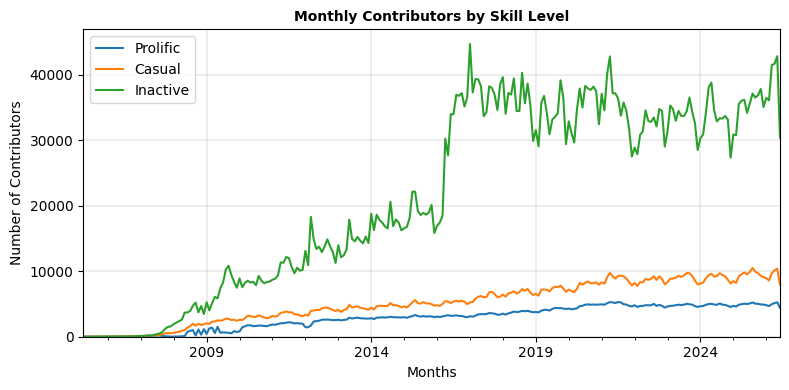

In [48]:
fig, ax = plt.subplots(figsize=(8, 4))

monthly_ctypes_wrld.plot(x = "month",
                        ax = ax)

ax.set_ylabel("Number of Contributors")
ax.set_xlabel("Months")

ax.set_title("Monthly Contributors by Skill Level", fontsize=10, fontweight="bold")
ax.legend()
ax.grid(linewidth=0.2, color = "gray")
ax.set_ylim(0,)
#ax.set_xlim("2020-01","2026-05")
plt.tight_layout()
plt.savefig("../results/monthly_contribs_skill_level_ohsome.png", dpi=150)


In [10]:
# check
print(
    monthly_acc_wrld_20.groupby("contributor_type", observed=True)
    .agg(n_users=("user_id", "count"), total_edits=("total_edits", "sum"))
    .assign(
        pct_users  = lambda d: (d.n_users      / d.n_users.sum()      * 100).round(2),
        pct_edits  = lambda d: (d.total_edits  / d.total_edits.sum()  * 100).round(2),
    )
)

                  n_users          total_edits            pct_users  \
contributor_type                                                      
Casual             632355    17,140,088,607.00                18.37   
Inactive          2462050     3,638,068,638.00                71.51   
Prolific           348468   117,077,795,695.00                10.12   

                            pct_edits  
contributor_type                       
Casual                          12.43  
Inactive                         2.64  
Prolific                        84.93  
